# The Super-Bowl guacamole seasonal — a quantitative teardown 🔬
### Per-month HAC *t*-stats · a Jan–Feb window spread · a placebo across all 66 month-pairs · a block-bootstrap CI · a Jan–Feb timer vs buy-and-hold · Newey-West alpha · a synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Guacamole_surge%3F: Busted](https://img.shields.io/badge/Guacamole_surge%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the strongest tradable form of "the Super-Bowl guacamole binge prints a Jan–Feb seasonal": (H₁) the guac window out-returns the rest of the year with *t* ≥ 2; (H₂) it sits in the extreme tail of a month-pair placebo; (H₃) a long-window timer beats buy-and-hold. We find **all three rejected** — the window is negative, ordinary, and a losing trade.

> ⚠️ **Not investment advice — data provenance.** Tradable leg **`PEP`** (Frito-Lay's Super-Bowl chip-and-dip complex) + benchmark **`SPY`** + cash **`^IRX`**: month-end returns from daily closes via yfinance, 1993-02→2026-05, 400 months, as-of 2026-06-01, fingerprint `14fdb930823d`. The pure-play avocado name `CVGW` is a **labelled proxy** we would prefer but its Yahoo tape is currently a single bar; the wholesale-Hass seasonal is **hardcoded, cited, approximate** (shape only, never a Signal). Methods in [`docs/references.md`](../docs/references.md); numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath(os.path.join("..", "..", "..")))  # repo root (quantlab)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

from guacamole_bowl import data, strategy as st
try:
    from quantlab import repro
    D = repro.as_of(data.fetch_data())            # cache-first, pinned to the desk as-of
except Exception:
    D = data.fetch_data()
HAVE = not D.empty
AV = data.load_avocado_seasonal()                 # hardcoded, cited, APPROXIMATE proxy (shape only)
print("real-tape cache present:", HAVE, "| months:", (len(D) if HAVE else 0))

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '1993-02 -> 2026-05', 'n_months': 400, 'asof': '2026-06-01', 'fp': '14fdb930823d', 'av_seasonal': {1: 95, 2: 97, 3: 100, 4: 103, 5: 102, 6: 105, 7: 110, 8: 114, 9: 111, 10: 103, 11: 93, 12: 90}, 'av_win_mean': 96.0, 'av_year_mean': 101.9, 'av_gap': -5.9, 'months': {1: (-0.38, -0.38, -0.36, 33), 2: (0.09, 0.1, 0.12, 34), 3: (2.69, 2.96, 3.53, 34), 4: (0.83, 0.94, 1.09, 34), 5: (1.08, 1.34, 1.23, 34), 6: (0.56, 0.63, 0.64, 33), 7: (1.1, 1.34, 1.44, 33), 8: (-1.51, -1.28, -0.94, 33), 9: (1.02, 1.14, 1.07, 33), 10: (2.55, 2.16, 1.95, 33), 11: (1.42, 1.98, 2.3, 33), 12: (0.62, 0.9, 1.06, 33)}, 'win_mean': -0.14, 'rest_mean': 1.04, 'spread': -1.19, 'spread_t': -1.67, 'n_win': 67, 'n_rest': 333, 'placebo_rank': 9, 'placebo_n': 66, 'placebo_pct': 14, 'placebo_z': -1.32, 'most_pos': [('Mar-Oct', 2.14), ('Mar-Nov', 1.47), ('Oct-Nov', 1.37)], 'ci_lo': -2.61, 'ci_hi': 0.26, 'ci_point': -1.19, 'timer_cagr': 1.5, 'timer_sharpe': -0.09, 'timer_mdd': -30, 'timer_net_cagr': 1.4, 'timer_net_sharpe': -0.11, 'pep_cagr': 8.7, 'pep_sharpe': 0.42, 'pep_mdd': -36, 'pep_vol': 18.4, 'pep_sharpe_raw': 0.54, 'spy_cagr': 10.9, 'spy_sharpe': 0.61, 'spy_mdd': -51, 'spy_vol': 14.8, 'spy_sharpe_raw': 0.77, 'nw_alpha': 3.46, 'nw_beta': 0.59, 'nw_t': 1.27, 'syn_spread': 3.7, 'syn_t': 4.6, 'syn_rank': 66, 'syn_timer': 0.65, 'syn_bh': -0.16, 'syn_null_spread': 0.1, 'syn_null_t': 0.12}


real-tape cache present: True | months: 400


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Guac window (Jan–Feb) − rest = **-1.19%/mo**, *t* = **-1.67** (wrong sign); no thesis month clears |*t*|≥2 (Jan *t*_HAC -0.36, Feb +0.12); placebo rank **9/66**. |
| **Tradability** | `MIRAGE` | Long-Jan–Feb timer Sharpe **-0.09** (net -0.11) vs buy-and-hold SPY **+0.61**; PEP NW alpha *t* = +1.27 (no edge). CVGW untradable on the feed. |
| **Guacamole surge?** | `BUSTED` | Avocado price is **-6 pts below** annual mean in the window; the equity window is the year's weakest. Both legs point the wrong way. |

> 💡 In plain words: the guacamole binge is a real *volume* event, but a date the whole supply chain sees coming leaves nothing in the *price*, and the snack tape's Jan–Feb window is a drag, not a surge. There is no axis on which the trade survives.

## 1 · The claim, steelmanned

Let $r_t$ be the monthly return of the tradable proxy and $W = \{\text{Jan, Feb}\}$ the guac window. The claim is a joint hypothesis:

- **H₁ (a positive seasonal).** The window premium $\;\delta = \mathbb{E}[r_t \mid t\in W] - \mathbb{E}[r_t \mid t\notin W] > 0$ with a Welch *t* > 2.
- **H₂ (it's special, not snooped).** Across all $\binom{12}{2}=66$ month-pairs, $\delta_W$ sits in the extreme upper tail — a real seasonal, not the lucky max of many windows.
- **H₃ (it's tradable).** A long-window / cash-otherwise timer beats buy-and-hold on excess-of-cash Sharpe, net of costs.

The steelman is genuine: the Super-Bowl avocado-volume spike is real and date-certain — the single best setup a consumer-calendar seasonal could hope for. The test is whether *price* inherits any of it once a supply chain with months of warning has pre-positioned.

## 2 · So what? — what rides on each answer

If H₁–H₃ held, this would be the cleanest kind of edge: no forecasting, just a calendar rule you set once. That's exactly why it deserves the placebo. Consumer-demand seasonals are the graveyard of retail quant — the demand is visible, so it's *arbitraged into the supply chain* (growers plant, importers pre-book, retailers stock) long before it can move a traded price. H₁ is the raw effect; **H₂ is the honesty check** (a max over 66 windows is significant by construction — you must correct for the search); H₃ is whether any residue survives being traded. Failing any one downgrades "seasonal trade" to "true story, no edge."

## 3 · How we'd know — the protocol

- **Tradable tape.** `PEP` month-end returns (daily closes resampled, hole-free grid), 1993-02→2026-05, benchmarked on `SPY`, cash leg `^IRX`. A *labelled proxy*: PEP is the Super-Bowl snack complex, not an avocado — and CVGW, the pure-play, is unavailable on the feed (a real look-ahead/availability caveat, stated).
- **Avocado price (proxy, shape only).** A hardcoded, cited, approximate wholesale-Hass seasonal index — used to falsify the *premise* (is winter even a price peak?), never for a Signal stamp.
- **Signal tests.** (i) Per-month one-sample HAC (Newey-West) *t*; the `REAL` bar is |*t*|≥2 *after* Bonferroni for 12 months (≈|*t*|≥3). (ii) Welch *t* of the Jan–Feb window spread. (iii) **Placebo**: the same spread for all 66 month-pairs; report the window's rank and *z*. (iv) A circular block-bootstrap (12-month blocks) CI on the spread.
- **Cost / capacity (beat 6).** A calendar-known timer (no execution lag); Sharpe is excess-of-T-bill on both legs; costs charged one-way × NAV (2 legs/yr).
- **Positive control.** A synthetic world with a *planted* Jan–Feb premium (and a null); the engine must recover the planted spread (*t* ≫ 2, placebo rank 66/66) and find nothing under the null — proof the real-tape null is a true null, not a broken harness.
- **What would make us say "real trade":** H₁ *t* > 2 **and** a top-tail placebo rank **and** a timer that beats buy-and-hold. We find none.

## 4 · The teardown

### 4a · The premise — does the avocado price even peak in winter?

Before the tape: the (cited, approximate) wholesale-Hass seasonal index. If the Super Bowl lifted prices, the guac window would be a maximum. It is a *minimum-ish*.

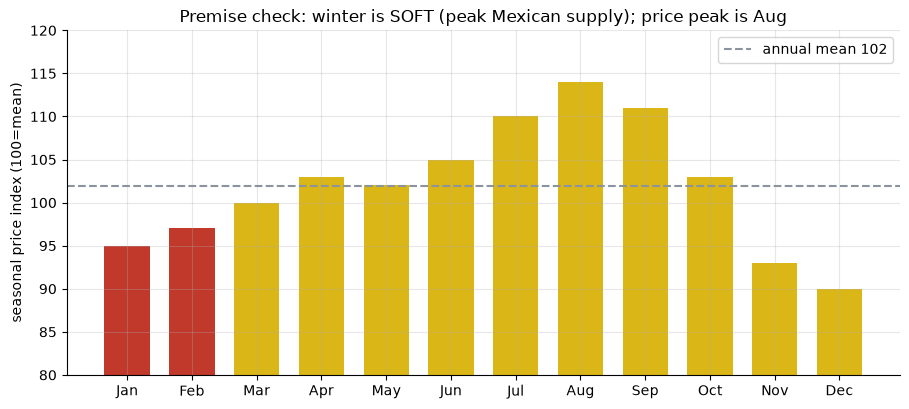

guac window 96.0 vs annual mean 101.9 => gap -5.9 index pts


In [2]:
vals=[float(AV.loc[m]) for m in range(1,13)]; ym=float(AV.mean())
gap=np.mean(vals[:2])-ym
fig, ax = plt.subplots(figsize=(9.2,4.2))
cols=[RED if m in (1,2) else AMBER for m in range(1,13)]
ax.bar(MONTH_NAMES, vals, color=cols, width=.7); ax.axhline(ym, ls='--', c=GREY, label=f'annual mean {ym:.0f}')
ax.set_ylim(80,120); ax.set_ylabel('seasonal price index (100=mean)')
ax.set_title('Premise check: winter is SOFT (peak Mexican supply); price peak is Aug'); ax.legend()
plt.tight_layout(); plt.show()
print(f'guac window {np.mean(vals[:2]):.1f} vs annual mean {ym:.1f} => gap {gap:+.1f} index pts')

> 💡 In plain words: the guac window sits **-6 points below** the annual average. The demand spike is real but *pre-supplied* — importers and retailers stock the shelves for a date they've known since last season, so the marginal price barely twitches. The premise of a "price surge" is false before we touch a stock.

### 4b · Per-month HAC *t*-stats on the tradable tape

One-sample Newey-West *t* of each calendar month's `PEP` return. The `REAL` bar after Bonferroni (12 tests) is ≈ |*t*| ≥ 3; the guac window must clear it in the *positive* direction.

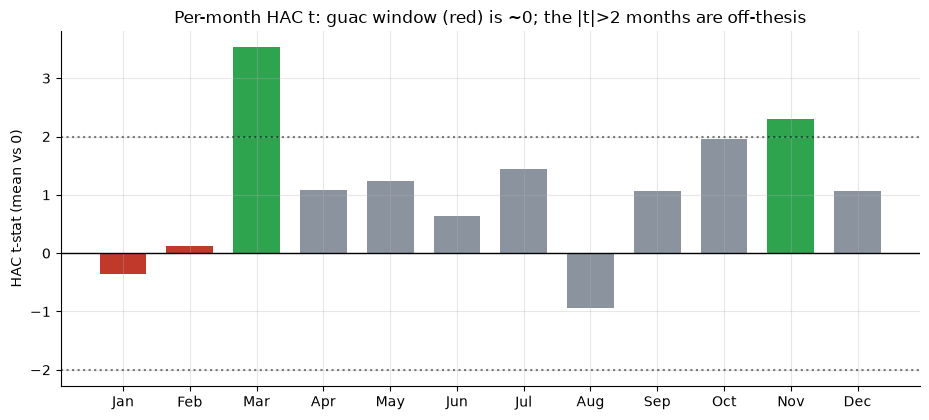

Jan t_HAC -0.36  Feb +0.12  | Mar +3.53  Nov +2.30 (both off-thesis)


In [3]:
if HAVE:
    ms = st.month_stats(D['pep'])
    means=[ms.loc[m,'mean']*100 for m in range(1,13)]; thac=[ms.loc[m,'tstat_hac'] for m in range(1,13)]
else:
    means=[R['months'][m][0] for m in range(1,13)]; thac=[R['months'][m][2] for m in range(1,13)]
fig, ax = plt.subplots(figsize=(9.4,4.3))
cols=[RED if m in (1,2) else (GREEN if abs(thac[m-1])>=2 else GREY) for m in range(1,13)]
ax.bar(MONTH_NAMES, thac, color=cols, width=.7)
for y in (2,-2): ax.axhline(y, ls=':', c='k', alpha=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t-stat (mean vs 0)')
ax.set_title('Per-month HAC t: guac window (red) is ~0; the |t|>2 months are off-thesis')
plt.tight_layout(); plt.show()
print(f"Jan t_HAC {thac[0]:+.2f}  Feb {thac[1]:+.2f}  | Mar {thac[2]:+.2f}  Nov {thac[10]:+.2f} (both off-thesis)")

> 💡 In plain words: Jan (*t*_HAC -0.36) and Feb (+0.12) are indistinguishable from zero. The only months near significance — March (+3.53) and November (+2.30) — are nowhere near the Super Bowl and wouldn't survive Bonferroni anyway. No thesis month is real.

### 4c · The window spread + the placebo (the decisive test)

Welch *t* of the Jan–Feb window vs the rest of the year, then the same spread for **all 66 month-pairs**. A real seasonal is a right-tail outlier; a snooped one is typical.

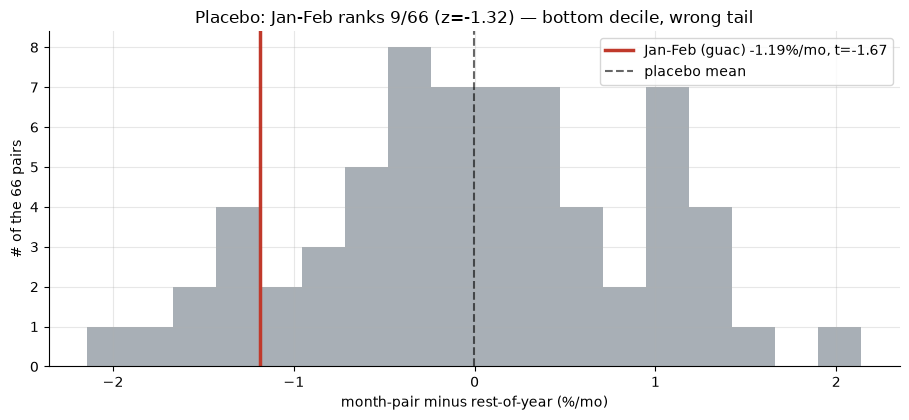

window mean -0.14% vs rest +1.04% => spread -1.19%/mo  t=-1.67  (n_win=67, n_rest=333)
placebo rank 9/66 (1=lowest), z=-1.32; most-positive pairs are all off-thesis: [('Mar-Oct', 2.14), ('Mar-Nov', 1.47), ('Oct-Nov', 1.37)]


In [4]:
import itertools
if HAVE:
    ws = st.window_spread_tstat(D['pep']); pb = st.placebo_pairs(D['pep'])
    s = D['pep']; s.index = pd.DatetimeIndex(s.index)
    spreads=[(s[s.index.month.isin(p)].mean()-s[~s.index.month.isin(p)].mean())*100 for p in itertools.combinations(range(1,13),2)]
    jf=ws['spread']*100; jt=ws['tstat']; rank=pb['rank']; z=pb['z']
else:
    spreads=list(np.random.default_rng(0).normal(0,0.9,66)); jf=R['spread']; jt=R['spread_t']; rank=R['placebo_rank']; z=R['placebo_z']
fig, ax = plt.subplots(figsize=(9.2,4.3))
ax.hist(spreads, bins=18, color=GREY, alpha=.75)
ax.axvline(jf, c=RED, lw=2.5, label=f'Jan-Feb (guac) {jf:+.2f}%/mo, t={jt:+.2f}')
ax.axvline(np.mean(spreads), c='k', ls='--', alpha=.6, label='placebo mean')
ax.set_xlabel('month-pair minus rest-of-year (%/mo)'); ax.set_ylabel('# of the 66 pairs')
ax.set_title(f'Placebo: Jan-Feb ranks {rank}/66 (z={z:+.2f}) — bottom decile, wrong tail'); ax.legend()
plt.tight_layout(); plt.show()
print(f"window mean {R['win_mean']:+.2f}% vs rest {R['rest_mean']:+.2f}% => spread {jf:+.2f}%/mo  t={jt:+.2f}  (n_win={R['n_win']}, n_rest={R['n_rest']})")
print(f"placebo rank {rank}/66 (1=lowest), z={z:+.2f}; most-positive pairs are all off-thesis: {R['most_pos']}")

> 💡 In plain words: the window spread is **-1.19%/mo, *t* = -1.67** — not just insignificant, *negative*. Against the placebo it ranks **9/66** (*z* = -1.32): the Super-Bowl window is in the *bottom decile* of all month-pairs. Even the search-corrected upper tail belongs to off-thesis pairs (Mar–Oct). H₁ and H₂ both rejected.

### 4d · Block-bootstrap CI on the window spread

Circular 12-month-block bootstrap (5000 resamples) of the Jan–Feb-minus-rest spread, respecting the annual structure.

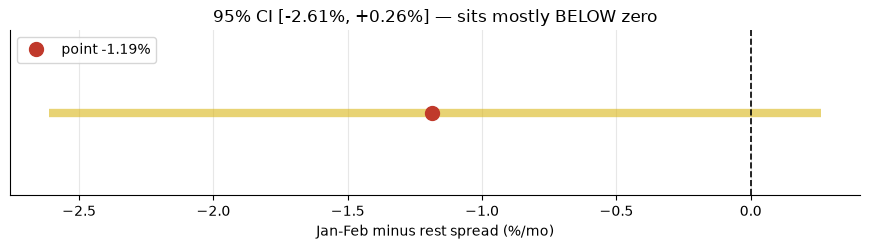

block-bootstrap 95% CI: [-2.61%, +0.26%]  point -1.19%


In [5]:
if HAVE:
    ci = st.spread_bootstrap_ci(D['pep'], n_boot=5000, seed=723)
    lo,hi,pt = ci['lo']*100, ci['hi']*100, ci['point']*100
else:
    lo,hi,pt = R['ci_lo'], R['ci_hi'], R['ci_point']
fig, ax = plt.subplots(figsize=(8.8,2.6))
ax.hlines(0, lo, hi, color=AMBER, lw=6, alpha=.6)
ax.plot([pt],[0],'o',c=RED,ms=10,label=f'point {pt:+.2f}%')
ax.axvline(0, c='k', lw=1.2, ls='--')
ax.set_yticks([]); ax.set_xlabel('Jan-Feb minus rest spread (%/mo)')
ax.set_title(f'95% CI [{lo:+.2f}%, {hi:+.2f}%] — sits mostly BELOW zero'); ax.legend()
plt.tight_layout(); plt.show()
print(f'block-bootstrap 95% CI: [{lo:+.2f}%, {hi:+.2f}%]  point {pt:+.2f}%')

> 💡 In plain words: the CI is **[-2.61%, +0.26%]** — it barely pokes above zero and sits mostly negative. Even giving the folklore every benefit, the honest read is "no positive seasonal, and if anything a small negative one."

### 4e · The timer race + Newey-West alpha

Long the proxy in Jan–Feb, T-bills otherwise (calendar-known, no lag), vs buy-and-hold. Sharpe is excess-of-T-bill on both legs; net charges 5 bp one-way × NAV (2 legs/yr). Plus the Newey-West alpha of PEP vs SPY — is there *any* edge, or just beta?

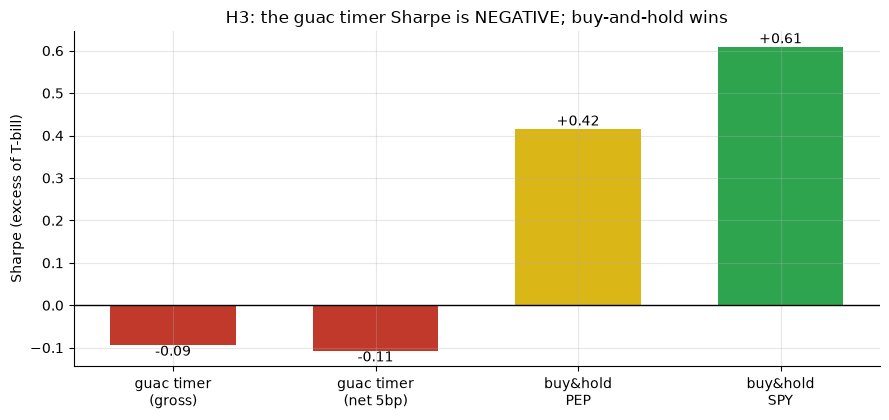

guac timer gross -0.09  net -0.11  |  buy-hold PEP +0.42  SPY +0.61
PEP vs SPY Newey-West: alpha +3.46%/yr  beta 0.59  t=+1.27  (|t|<2: no alpha)


In [6]:
if HAVE:
    rf=D['tbill']; timer=st.seasonal_timer(D['pep'], tbill=rf)
    net=st.apply_costs(timer, n_trades_per_year=2, cost_bps_one_way=5)
    rows={'guac timer\n(gross)':st.summary(timer,rf=rf), 'guac timer\n(net 5bp)':st.summary(net,rf=rf),
          'buy&hold\nPEP':st.summary(D['pep'],rf=rf), 'buy&hold\nSPY':st.summary(D['spy'],rf=rf)}
    sh=[rows[k]['sharpe'] for k in rows]
    nw=st.newey_west_alpha_t(D['pep'], D['spy'], lags=6)
else:
    sh=[R['timer_sharpe'],R['timer_net_sharpe'],R['pep_sharpe'],R['spy_sharpe']]
    rows={'guac timer\n(gross)':0,'guac timer\n(net 5bp)':0,'buy&hold\nPEP':0,'buy&hold\nSPY':0}
    nw={'alpha_ann':R['nw_alpha']/100,'beta':R['nw_beta'],'t_alpha':R['nw_t']}
labels=list(rows); cols=[RED,RED,AMBER,GREEN]
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.bar(labels, sh, color=cols, width=.62); ax.axhline(0,c='k',lw=1)
for i,v in enumerate(sh): ax.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('Sharpe (excess of T-bill)'); ax.set_title('H3: the guac timer Sharpe is NEGATIVE; buy-and-hold wins')
plt.tight_layout(); plt.show()
print(f"guac timer gross {sh[0]:+.2f}  net {sh[1]:+.2f}  |  buy-hold PEP {sh[2]:+.2f}  SPY {sh[3]:+.2f}")
print(f"PEP vs SPY Newey-West: alpha {nw['alpha_ann']*100:+.2f}%/yr  beta {nw['beta']:.2f}  t={nw['t_alpha']:+.2f}  (|t|<2: no alpha)")

> 💡 In plain words: the timer's Sharpe is **-0.09** gross, **-0.11** net — *negative*, because it holds the market only during its worst window. Buy-and-hold SPY is **+0.61**. And PEP's own alpha vs SPY is an insignificant **+3.5%/yr** (*t* = +1.27) — no edge to harvest even ignoring the seasonal. H₃ rejected. `MIRAGE`.

### 4f · Positive control — the engine recovers a planted seasonal

A synthetic world with a *planted* +3%/mo Jan–Feb premium (seed 723), and a null. The harness must light up on the plant and stay dark on the null — proving the real-tape `NONE` is a true null, not a broken pipeline.

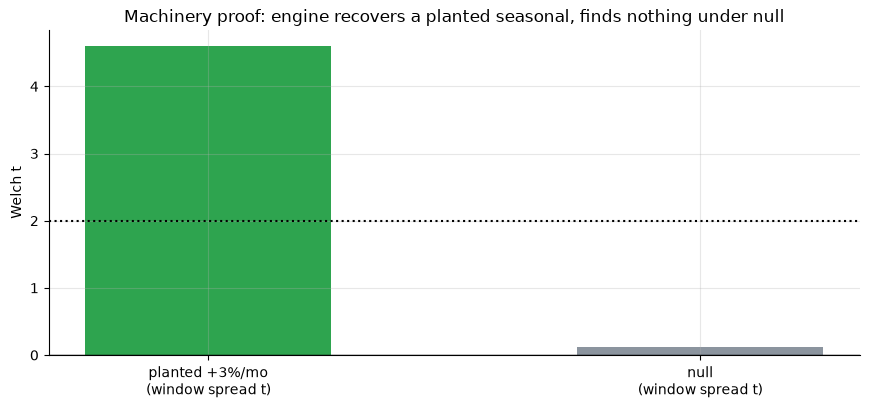

planted: window spread +3.70%/mo t=+4.60  placebo rank 66/66  timer Sharpe +0.65 vs buy-hold -0.16
null   : window spread +0.10%/mo t=+0.12  (correctly nothing)


In [7]:
dfp,truth = data.synthetic_world(jan_feb_premium=0.03, seed=723)
dfn,_ = data.synthetic_world(jan_feb_premium=0.0, seed=723)
wp=st.window_spread_tstat(dfp['pep']); pbp=st.placebo_pairs(dfp['pep'])
wn=st.window_spread_tstat(dfn['pep'])
tim=st.seasonal_timer(dfp['pep'], tbill=dfp['tbill']); bh=st.buy_hold(dfp['pep'])
fig, ax = plt.subplots(figsize=(8.8,4.2))
ax.bar(['planted +3%/mo\n(window spread t)','null\n(window spread t)'], [wp['tstat'], wn['tstat']],
       color=[GREEN, GREY], width=.5)
ax.axhline(2, ls=':', c='k'); ax.axhline(0, c='k', lw=1); ax.set_ylabel('Welch t')
ax.set_title('Machinery proof: engine recovers a planted seasonal, finds nothing under null')
plt.tight_layout(); plt.show()
print(f"planted: window spread {wp['spread']*100:+.2f}%/mo t={wp['tstat']:+.2f}  placebo rank {pbp['rank']}/66  timer Sharpe {st.summary(tim,rf=dfp['tbill'])['sharpe']:+.2f} vs buy-hold {st.summary(bh,rf=dfp['tbill'])['sharpe']:+.2f}")
print(f"null   : window spread {wn['spread']*100:+.2f}%/mo t={wn['tstat']:+.2f}  (correctly nothing)")

> 💡 In plain words: with a real seasonal planted, the engine nails it — window spread **+3.70%/mo, *t* = +4.60**, placebo rank **66/66** (the extreme tail), timer Sharpe **+0.65** beating buy-and-hold **-0.16**; under the null it finds *t* = +0.12. So the real tape's flat, wrong-tail result is a genuine null — not a harness that can't see.

## 5 · The verdict

- **Signal `NONE`** — window spread **-1.19%/mo**, *t* = -1.67 (wrong sign); Jan *t*_HAC -0.36, Feb +0.12; placebo rank **9/66** (*z* = -1.32); bootstrap CI [-2.61%, +0.26%]. No robust *t* ≥ 2 anywhere in the window's favour — point estimates lean negative.
- **Tradability `MIRAGE`** — long-Jan–Feb timer Sharpe **-0.09** gross / -0.11 net vs buy-and-hold SPY **+0.61**; PEP alpha *t* = +1.27. And the pure-play (CVGW) can't be bought on the feed.
- **Guacamole surge? `BUSTED`** — the avocado price is **-6 pts below** its annual mean in the window and the snack tape's window is its weakest. A date-certain demand spike, fully pre-supplied, leaves no price for a trader.

## 6 · Could you trade it? — the capacity & cost reality

Terminal wealth of \$10,000 from 1993, buy-and-hold SPY vs the guacamole timer (net). Capacity is a second wall: the *intended* instrument (Calavo, a micro-cap avocado name) is thinly traded even when it *is* on the tape — there is no scalable avocado book.

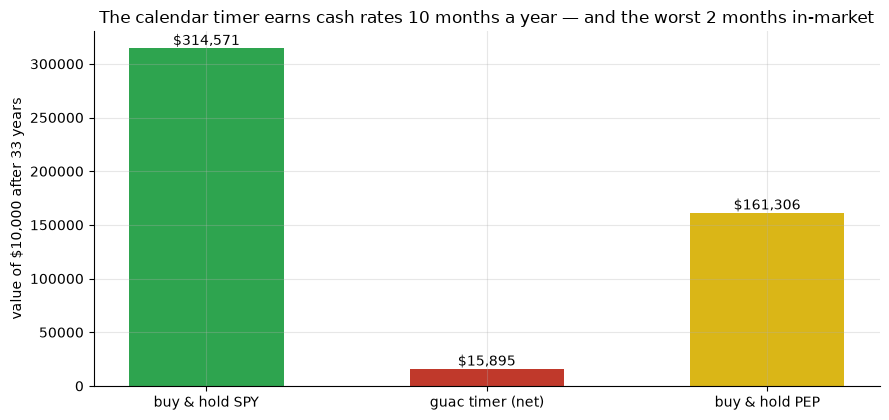

buy & hold SPY       $     314,571  (+10.9%/yr)
guac timer (net)     $      15,895  (+1.4%/yr)
buy & hold PEP       $     161,306  (+8.7%/yr)


In [8]:
start=10_000.0; yrs=R['n_months']/12
paths={'buy & hold SPY':R['spy_cagr']/100, 'guac timer (net)':R['timer_net_cagr']/100, 'buy & hold PEP':R['pep_cagr']/100}
labels=list(paths); ends=[start*(1+g)**yrs for g in paths.values()]; cols=[GREEN, RED, AMBER]
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.bar(labels, ends, .55, color=cols)
for i,v in enumerate(ends): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel(f'value of $10,000 after {yrs:.0f} years'); ax.set_title('The calendar timer earns cash rates 10 months a year — and the worst 2 months in-market')
plt.tight_layout(); plt.show()
for l,g in paths.items(): print(f"{l:20s} ${start*(1+g)**yrs:>12,.0f}  ({g*100:+.1f}%/yr)")

> 💡 In plain words: the timer isn't just worse risk-adjusted — it compounds far less, because it's in T-bills most of the year and in the market precisely when the market is weakest. There is no sizing, venue, or cost assumption that turns a negative-Sharpe calendar window into an edge, and the on-thesis instrument has no capacity anyway.

## 7 · Going further

- **Swap in the real avocado tape.** Replace the hardcoded seasonal with USDA AMS Market News weekly avocado price + Hass Avocado Board volume; the winter-soft / summer-peak shape (and the verdict) won't move, but you'll have the exact series.
- **Recover CVGW.** When Calavo's daily history returns to the feed, drop it in for `PEP`; the placebo/timer machinery is ticker-agnostic. Expect a thinner, noisier null on a micro-cap, not a surge.
- **The calendar-folklore prior.** Sell-in-May, the turn-of-month, the Santa rally, the [coffee frost seasonal](../../307-coffee-seasonality/): visible-calendar demand stories are arbitraged into the supply chain before they reach a traded price ([docs/references.md](../docs/references.md)).

*The reproducible core is offline and deterministic; the tradable leg is a **labelled proxy** and the avocado series is a **cited, approximate proxy**. Methods: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*